In [24]:

import sys, os
sys.path.append(os.path.join(os.getcwd(), '..'))
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Step 1 — Data Preparation

In [25]:
from src.data_preparation import run_data_preparation
df_train_clean, df_eval_clean = run_data_preparation(city_id=0)

Loading Dingdong-Inc/FreshRetailNet-50K...
Filtered city_id=0
Train : (2322990, 19)
Eval  : (180677, 19)

Flatten & rename...

Cleaning train...
  drop_duplicates : 2322990 → 2322990 rows
  winsorize       : 13 rows capped tại 23.200
  final shape     : (2322989, 20)

Cleaning eval...
  drop_duplicates : 180677 → 180677 rows
  winsorize       : 1 rows capped tại 29.480
  final shape     : (180677, 20)

✓ Saved to data/raw/


## Step 2 — Feature Engineering

In [26]:
from src.feature_engineering import run_feature_engineering, FEATURE_COLS, TARGET_COL

X_train, X_test, y_train, y_test = run_feature_engineering(
    df_train_clean,
    df_eval_clean,
    test_ratio=0.2,
)

print(f'Features : {len(FEATURE_COLS)}')
print(f'Target   : {TARGET_COL}')


Creating features (train)...
  features created : (2322989, 34)
Creating features (eval)...
  features created : (180677, 34)

Time-based split...
  cutoff date : 2024-06-07
  train       : 1,832,581 rows (2024-03-28 → 2024-06-06)
  test        : 490,408 rows  (2024-06-07 → 2024-06-25)

Filling NaN...
  NaN sau fill — train: 0, test: 0

✓ Saved to data/processed/
  X_train : (1832581, 24)
  X_test  : (490408, 24)
Features : 24
Target   : units_ordered


## Step 3 — EDA Visualizations

In [27]:
# Load processed train to visualize
train_df = pd.read_parquet('../data/processed/train.parquet')

print('Shape     :', train_df.shape)
print('Date range:', train_df['date'].min().date(), '→', train_df['date'].max().date())
print('Nulls     :')
print(train_df[FEATURE_COLS].isnull().sum()[lambda x: x > 0])

Shape     : (1832581, 34)
Date range: 2024-03-28 → 2024-06-06
Nulls     :
Series([], dtype: int64)


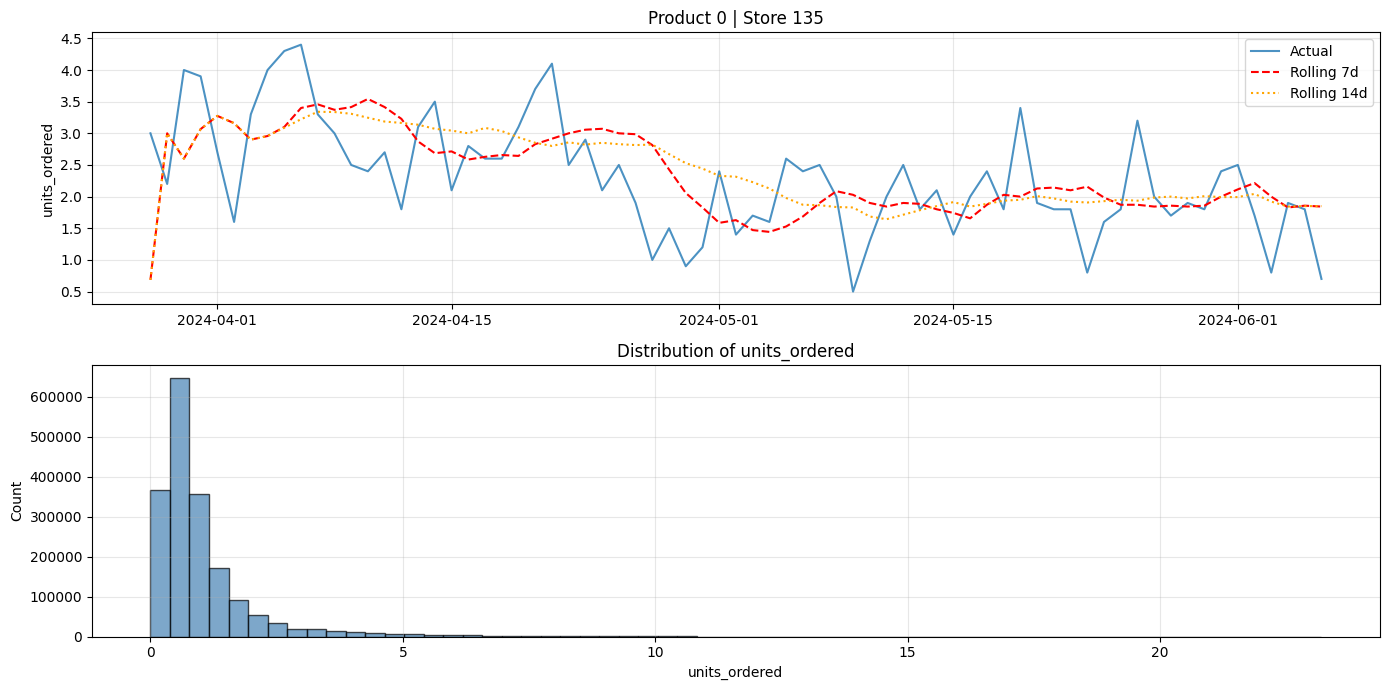

In [ ]:
# Plot 1: Sales in 1 product-store time by time
sample = (
    train_df[
        (train_df['product_id'] == train_df['product_id'].iloc[0]) &
        (train_df['store_id']   == train_df['store_id'].iloc[0])
    ]
    .sort_values('date')
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(sample['date'], sample['units_ordered'],    label='Actual',       alpha=0.8)
axes[0].plot(sample['date'], sample['rolling_mean_7'],   label='Rolling 7d',   linestyle='--', color='red')
axes[0].plot(sample['date'], sample['rolling_mean_14'],  label='Rolling 14d',  linestyle=':',  color='orange')
axes[0].set_title(f"Product {sample['product_id'].iloc[0]} | Store {sample['store_id'].iloc[0]}")
axes[0].set_ylabel('units_ordered')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(train_df['units_ordered'], bins=60, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_title('Distribution of units_ordered')
axes[1].set_xlabel('units_ordered')
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/data/processed/eda_plot.png', dpi=100)
plt.show()

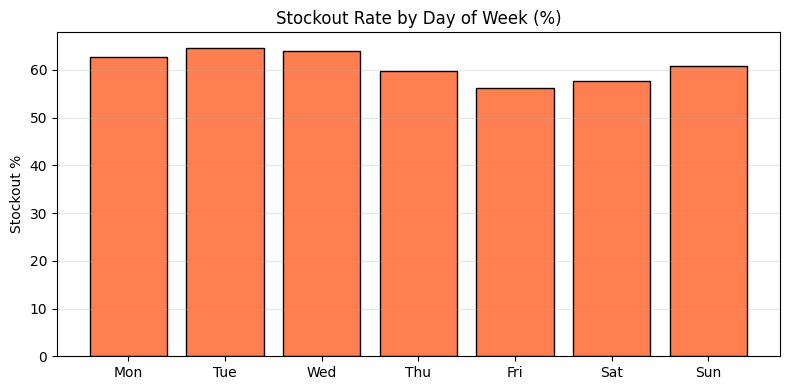

In [29]:
# Plot 2: Stockout rate by date in weeks
stockout_by_dow = train_df.groupby('day_of_week')['stockout_flag'].mean() * 100
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_labels, stockout_by_dow.values, color='coral', edgecolor='black')
ax.set_title('Stockout Rate by Day of Week (%)')
ax.set_ylabel('Stockout %')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

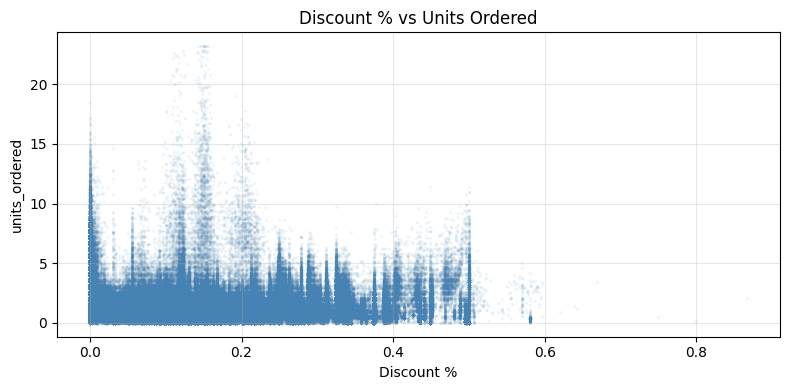

In [30]:
# Plot 3: Discount vs Sales
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(train_df['discount_pct'], train_df['units_ordered'],
           alpha=0.05, s=2, color='steelblue')
ax.set_title('Discount % vs Units Ordered')
ax.set_xlabel('Discount %')
ax.set_ylabel('units_ordered')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
